# Netflix Movies and TV Shows - Exploratory Data Analysis Project

This notebook is created according to the uploaded **netflix_titles.csv** dataset.  
It performs complete EDA with data cleaning, feature engineering, visualizations, outlier analysis, multivariate analysis, and business insights.

**Dataset columns used:**  
`show_id`, `type`, `title`, `director`, `cast`, `country`, `date_added`, `release_year`, `rating`, `duration`, `listed_in`, `description`

## Task 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

# Create folder for saving graphs
GRAPH_DIR = "netflix_eda_graphs"
os.makedirs(GRAPH_DIR, exist_ok=True)

def save_plot(filename):
    """Save current matplotlib figure into graph folder."""
    plt.tight_layout()
    plt.savefig(os.path.join(GRAPH_DIR, filename + ".png"), dpi=180, bbox_inches="tight")
    plt.show()

## Task 2: Load Dataset and Dataset Understanding

In [ ]:
# Load dataset
netflix = pd.read_csv("netflix_titles.csv")

print("Dataset Shape:", netflix.shape)
print("\nColumns:")
print(netflix.columns.tolist())

netflix.head()

Dataset Shape: (8807, 12)

Columns:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
# Basic information about dataset
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
# Missing values before cleaning
missing_before = netflix.isnull().sum().sort_values(ascending=False)
print("Missing Values Before Cleaning:")
print(missing_before)

# Duplicate rows
print("\nDuplicate Rows:", netflix.duplicated().sum())

Missing Values Before Cleaning:
director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

Duplicate Rows: 0


## Task 3: Data Cleaning

In [ ]:
# Make a copy for cleaning
df = netflix.copy()

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Remove duplicate records
df = df.drop_duplicates().reset_index(drop=True)

# In this Netflix dataset, some missing duration values are stored in rating column.
duration_mask = (
    df["duration"].isna() &
    df["rating"].astype(str).str.contains(r"\d+\s*min|\d+\s*Season", regex=True, na=False)
)

df.loc[duration_mask, "duration"] = df.loc[duration_mask, "rating"]
df.loc[duration_mask, "rating"] = np.nan

#Delete rows with missing values
df = df.dropna().reset_index(drop=True)

# Convert date_added into datetime
df["date_added"] = pd.to_datetime(
    df["date_added"].astype(str).str.strip(),
    errors="coerce"
)

# If any invalid dates become NaT, remove those rows too
df = df.dropna(subset=["date_added"]).reset_index(drop=True)

# Create added year and added month
df["added_year"] = df["date_added"].dt.year
df["added_month"] = df["date_added"].dt.month_name()

# Extract numeric duration
df["duration_number"] = (
    df["duration"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
    .astype(float)
)

# Separate duration for movies and TV Shows
df["movie_duration_min"] = np.where(
    df["type"] == "Movie",
    df["duration_number"],
    np.nan
)

df["tv_seasons"] = np.where(
    df["type"] == "TV Show",
    df["duration_number"],
    np.nan
)

# Final output
print("Dataset Shape After Cleaning:", df.shape)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

Dataset Shape After Cleaning: (5332, 17)

Missing Values After Cleaning:
show_id                  0
type                     0
title                    0
director                 0
cast                     0
country                  0
date_added               0
release_year             0
rating                   0
duration                 0
listed_in                0
description              0
added_year               0
added_month              0
duration_number          0
movie_duration_min     147
tv_seasons            5185
dtype: int64


In [ ]:
# Save cleaned dataset
df.to_csv("Netflix_Cleaned_EDA.csv", index=False)
print("Cleaned dataset saved as Netflix_Cleaned_EDA.csv")

Cleaned dataset saved as Netflix_Cleaned_EDA.csv


## Task 4: Content Type Analysis

Questions:
1. How many Movies?
2. How many TV Shows?
3. Percentage distribution.

In [ ]:
type_counts = df["type"].value_counts()
type_percentage = round((type_counts / len(df)) * 100, 2)

print("Content Type Count:")
print(type_counts)

print("\nContent Type Percentage:")
print(type_percentage)

Content Type Count:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Content Type Percentage:
type
Movie      69.62
TV Show    30.38
Name: count, dtype: float64


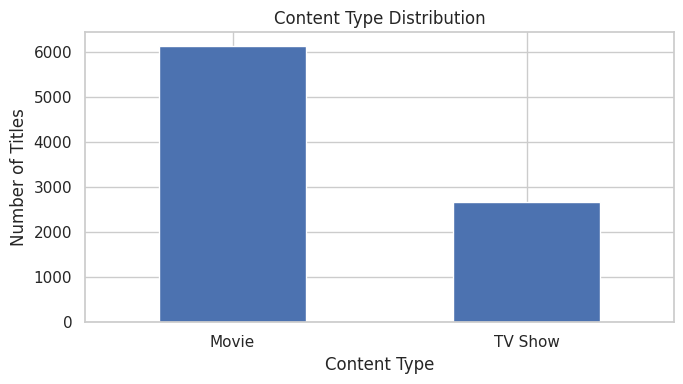

In [ ]:
plt.figure(figsize=(7, 4))
type_counts.plot(kind="bar")
plt.title("Content Type Distribution")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
save_plot("01_content_type_count")

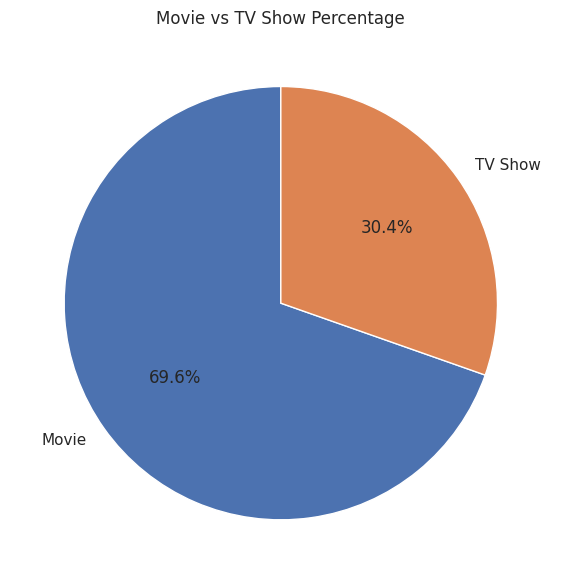

In [ ]:
plt.figure(figsize=(6, 6))
type_counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Movie vs TV Show Percentage")
plt.ylabel("")
save_plot("02_content_type_pie")

## Task 5: Country Analysis

Questions:
1. Top 10 content-producing countries.
2. Visualize country distribution.

In [ ]:
# Split multiple countries into separate rows
country_series = (
    df["country"]
    .replace("Unknown", np.nan)
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

top_10_countries = country_series.value_counts().head(10)

print("Top 10 Content-Producing Countries:")
print(top_10_countries)

Top 10 Content-Producing Countries:
country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


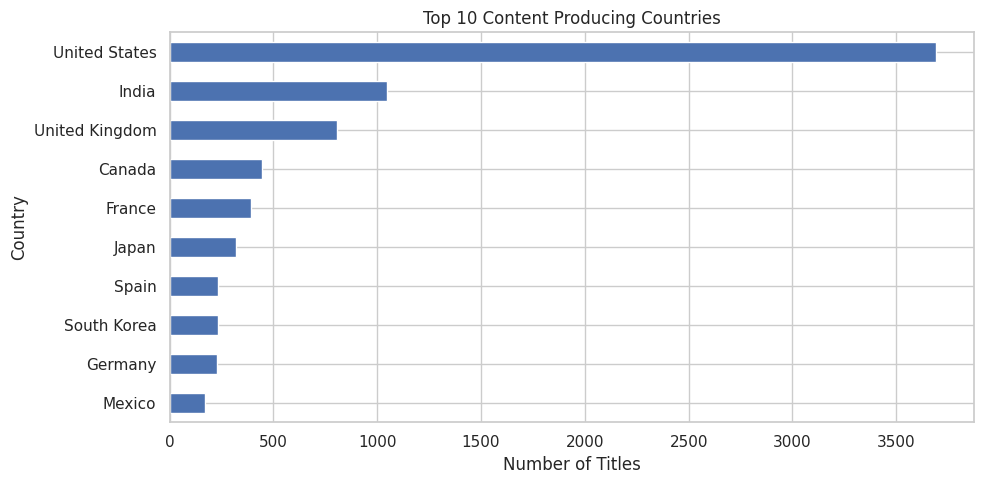

In [ ]:
plt.figure(figsize=(10, 5))
top_10_countries.sort_values().plot(kind="barh")
plt.title("Top 10 Content Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
save_plot("03_top_10_countries")

## Task 6: Yearly Trend Analysis

Questions:
1. Number of titles released each year.
2. Has content production increased over time?

In [ ]:
yearly_titles = df["release_year"].value_counts().sort_index()

print("Titles Released Each Year:")
print(yearly_titles.tail(20))

Titles Released Each Year:
release_year
2002      51
2003      61
2004      64
2005      80
2006      96
2007      88
2008     136
2009     152
2010     194
2011     185
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64


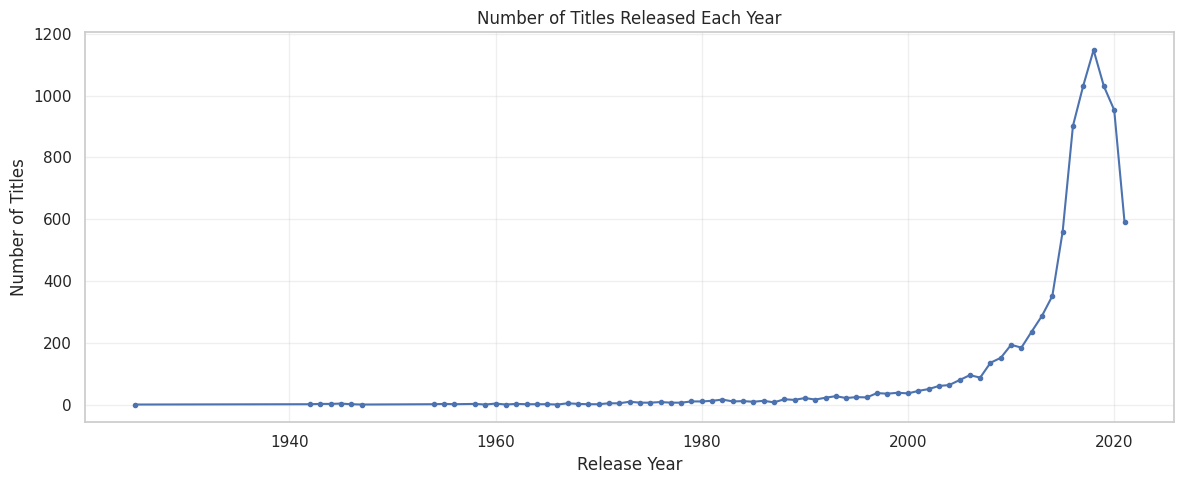

In [ ]:
plt.figure(figsize=(12, 5))
yearly_titles.plot(kind="line", marker="o", markersize=3)
plt.title("Number of Titles Released Each Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True, alpha=0.3)
save_plot("04_yearly_trend_line")

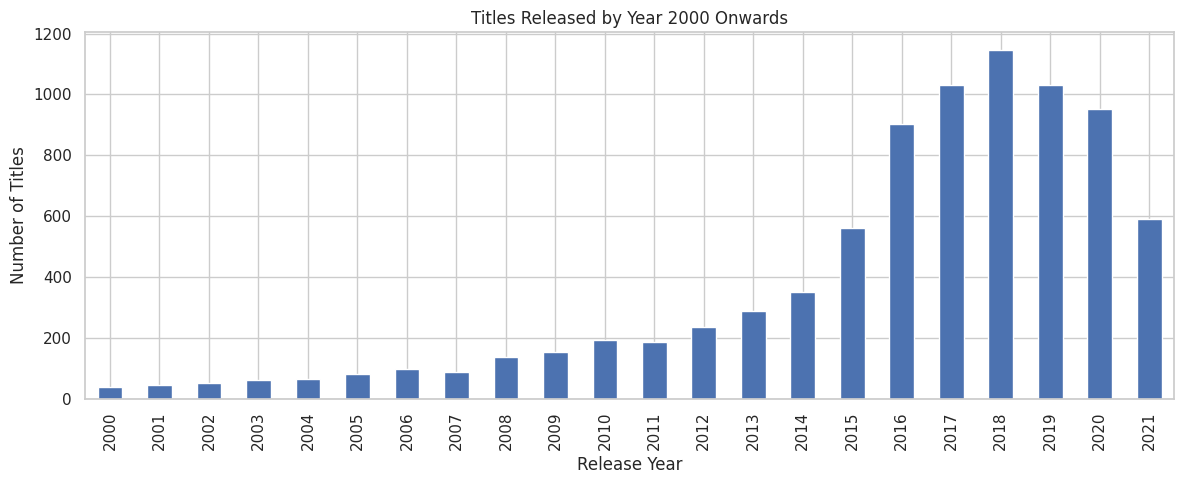

In [ ]:
recent_years = df[df["release_year"] >= 2000]["release_year"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
recent_years.plot(kind="bar")
plt.title("Titles Released by Year 2000 Onwards")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
save_plot("05_yearly_trend_bar")

## Task 7: Rating Analysis

Questions:
1. Most common maturity rating.
2. Distribution of ratings.
3. Visualize using countplot/bar chart.

In [ ]:
rating_counts = df["rating"].value_counts()

print("Most Common Rating:", rating_counts.idxmax())
print("\nRating Distribution:")
print(rating_counts)

Most Common Rating: TV-MA

Rating Distribution:
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
Unknown        7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


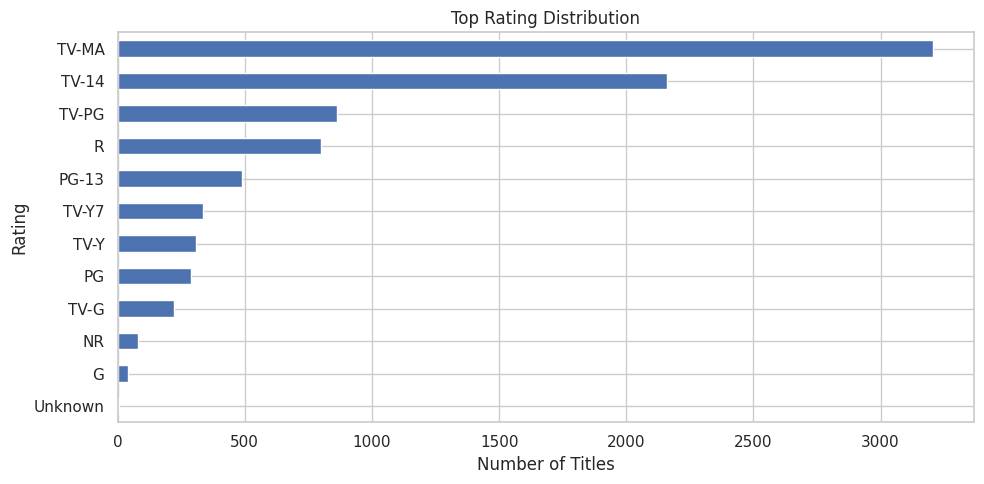

In [ ]:
plt.figure(figsize=(10, 5))
rating_counts.head(12).sort_values().plot(kind="barh")
plt.title("Top Rating Distribution")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
save_plot("06_rating_distribution")

## Task 8: Genre Analysis

Questions:
1. Top 10 genres.
2. Most popular genre category.
3. Visualize findings.

In [ ]:
genre_series = df["listed_in"].str.split(",").explode().str.strip()
top_10_genres = genre_series.value_counts().head(10)

print("Top 10 Genres:")
print(top_10_genres)

print("\nMost Popular Genre:", top_10_genres.idxmax())

Top 10 Genres:
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

Most Popular Genre: International Movies


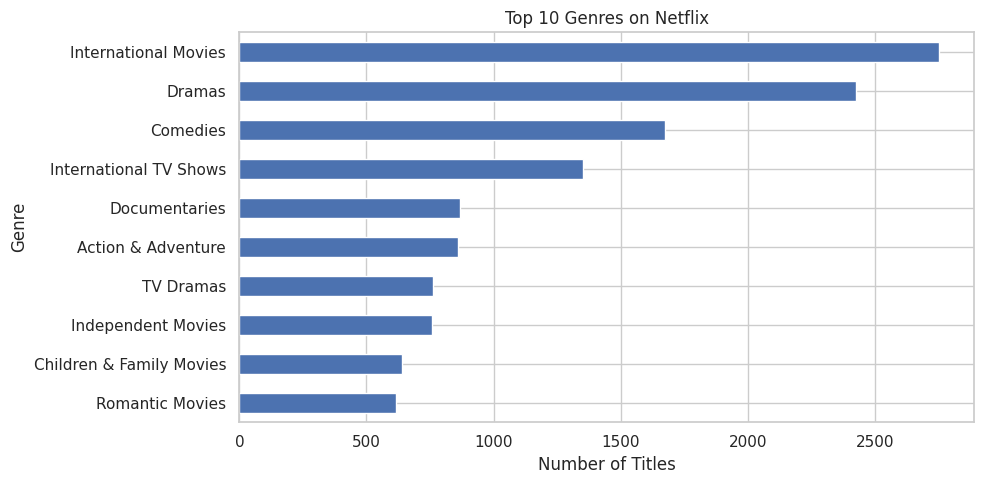

In [ ]:
plt.figure(figsize=(10, 5))
top_10_genres.sort_values().plot(kind="barh")
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
save_plot("07_top_10_genres")

## Task 9: Duration Analysis

Questions:
1. Average movie duration.
2. Longest movie.
3. Shortest movie.
4. Distribution of movie duration.

In [ ]:
movies = df[df["type"] == "Movie"].copy()

average_movie_duration = round(movies["movie_duration_min"].mean(), 2)
longest_movie = movies.loc[movies["movie_duration_min"].idxmax(), ["title", "movie_duration_min"]]
shortest_movie = movies.loc[movies["movie_duration_min"].idxmin(), ["title", "movie_duration_min"]]

print("Average Movie Duration:", average_movie_duration, "minutes")
print("\nLongest Movie:")
print(longest_movie)

print("\nShortest Movie:")
print(shortest_movie)

Average Movie Duration: 99.56 minutes

Longest Movie:
title                 Black Mirror: Bandersnatch
movie_duration_min                         312.0
Name: 4253, dtype: object

Shortest Movie:
title                 Silent
movie_duration_min       3.0
Name: 3777, dtype: object


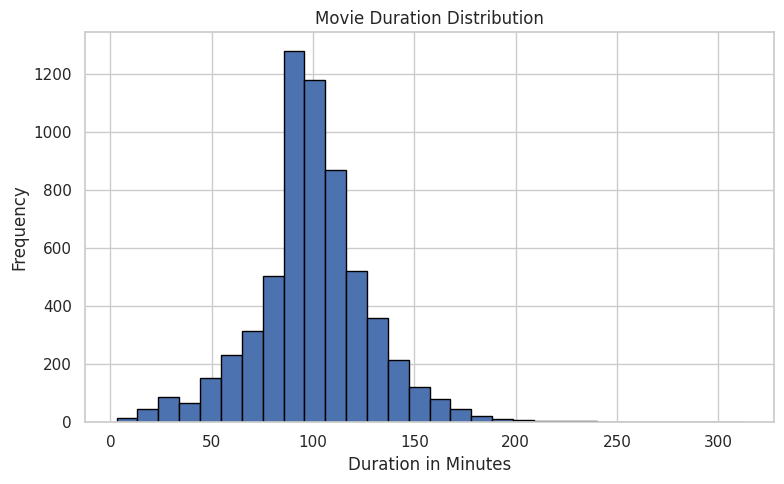

In [ ]:
plt.figure(figsize=(8, 5))
movies["movie_duration_min"].dropna().plot(kind="hist", bins=30, edgecolor="black")
plt.title("Movie Duration Distribution")
plt.xlabel("Duration in Minutes")
plt.ylabel("Frequency")
save_plot("08_movie_duration_histogram")

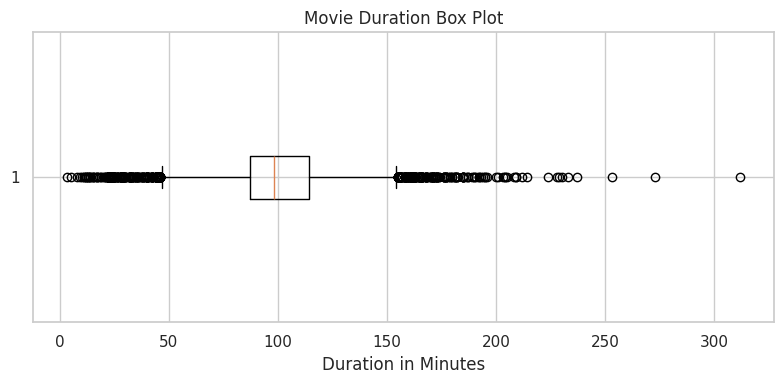

In [ ]:
plt.figure(figsize=(8, 4))
plt.boxplot(movies["movie_duration_min"].dropna(), vert=False)
plt.title("Movie Duration Box Plot")
plt.xlabel("Duration in Minutes")
save_plot("09_movie_duration_boxplot")

## Task 10: Outlier Analysis Using Movie Duration

Methods:
1. IQR method
2. Z-score method
3. Compare results

In [ ]:
# IQR Method
Q1 = movies["movie_duration_min"].quantile(0.25)
Q3 = movies["movie_duration_min"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

iqr_outliers = movies[
    (movies["movie_duration_min"] < lower_limit) |
    (movies["movie_duration_min"] > upper_limit)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
print("Number of IQR Outliers:", iqr_outliers.shape[0])

iqr_outliers[["title", "movie_duration_min"]].sort_values("movie_duration_min").head()

Q1: 87.0
Q3: 114.0
IQR: 27.0
Lower Limit: 46.5
Upper Limit: 154.5
Number of IQR Outliers: 450


,title,movie_duration_min
3777,Silent,3.0
2713,Sol Levante,5.0
1484,Cops and Robbers,8.0
1557,Canvas,9.0
3535,American Factory: A Conversation with the Obamas,10.0


In [ ]:
# Z-score Method
duration_values = movies["movie_duration_min"].dropna()
z_scores = np.abs((duration_values - duration_values.mean()) / duration_values.std())

z_outliers = movies.loc[duration_values.index[z_scores > 3]]

print("Number of Z-score Outliers:", z_outliers.shape[0])

z_outliers[["title", "movie_duration_min"]].sort_values("movie_duration_min").head()

Number of Z-score Outliers: 56


,title,movie_duration_min
3777,Silent,3.0
2713,Sol Levante,5.0
1484,Cops and Robbers,8.0
1557,Canvas,9.0
3535,American Factory: A Conversation with the Obamas,10.0


In [ ]:
print("Outlier Comparison:")
print("IQR Outliers:", iqr_outliers.shape[0])
print("Z-score Outliers:", z_outliers.shape[0])
print("\nObservation: IQR usually detects more outliers because it is based on quartile boundaries, while Z-score detects extreme values far from the mean.")

Outlier Comparison:
IQR Outliers: 450
Z-score Outliers: 56

Observation: IQR usually detects more outliers because it is based on quartile boundaries, while Z-score detects extreme values far from the mean.


## Task 11: Feature Engineering

Create:
1. Release Decade
2. Content Age
3. Duration Category
4. Season Category

In [ ]:
current_year = pd.Timestamp.today().year

# Release decade
df["release_decade"] = (df["release_year"] // 10 * 10).astype(str) + "s"

# Content age
df["content_age"] = current_year - df["release_year"]

# Duration category for movies
df["duration_category"] = pd.Series(index=df.index, dtype="object")
df.loc[(df["type"] == "Movie") & (df["movie_duration_min"] < 90), "duration_category"] = "Short"
df.loc[(df["type"] == "Movie") & (df["movie_duration_min"].between(90, 120)), "duration_category"] = "Medium"
df.loc[(df["type"] == "Movie") & (df["movie_duration_min"] > 120), "duration_category"] = "Long"

# Season category for TV Shows
df["season_category"] = pd.Series(index=df.index, dtype="object")
df.loc[(df["type"] == "TV Show") & (df["tv_seasons"] == 1), "season_category"] = "1 Season"
df.loc[(df["type"] == "TV Show") & (df["tv_seasons"].between(2, 3)), "season_category"] = "2-3 Seasons"
df.loc[(df["type"] == "TV Show") & (df["tv_seasons"] >= 4), "season_category"] = "4+ Seasons"

print("New Features Created Successfully!")
df[["title", "type", "release_year", "release_decade", "content_age", "duration", "duration_category", "season_category"]].head()

New Features Created Successfully!


,title,type,release_year,release_decade,content_age,duration,duration_category,season_category
0,Dick Johnson Is Dead,Movie,2020,2020s,6,90 min,Medium,NaN
1,Blood & Water,TV Show,2021,2020s,5,2 Seasons,NaN,2-3 Seasons
2,Ganglands,TV Show,2021,2020s,5,1 Season,NaN,1 Season
3,Jailbirds New Orleans,TV Show,2021,2020s,5,1 Season,NaN,1 Season
4,Kota Factory,TV Show,2021,2020s,5,2 Seasons,NaN,2-3 Seasons


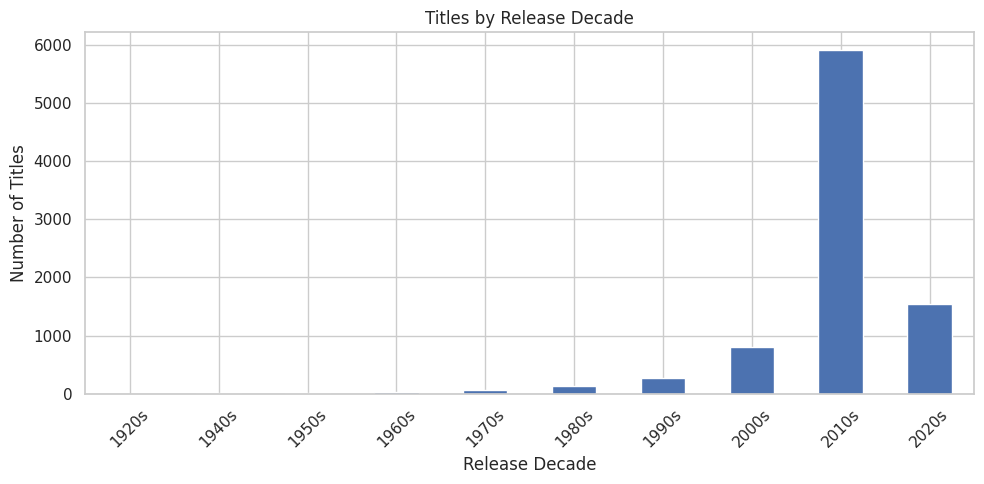

In [ ]:
plt.figure(figsize=(10, 5))
df["release_decade"].value_counts().sort_index().plot(kind="bar")
plt.title("Titles by Release Decade")
plt.xlabel("Release Decade")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
save_plot("10_release_decade_distribution")

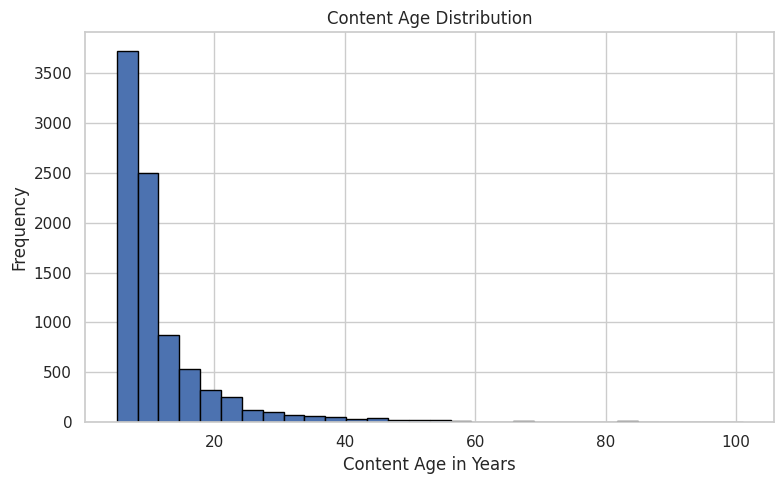

In [ ]:
plt.figure(figsize=(8, 5))
df["content_age"].plot(kind="hist", bins=30, edgecolor="black")
plt.title("Content Age Distribution")
plt.xlabel("Content Age in Years")
plt.ylabel("Frequency")
save_plot("11_content_age_distribution")

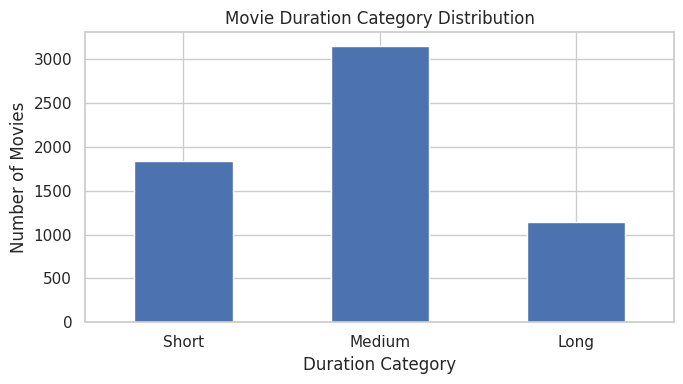

In [ ]:
plt.figure(figsize=(7, 4))
duration_counts = df[df["type"] == "Movie"]["duration_category"].value_counts().reindex(["Short", "Medium", "Long"])

duration_counts.plot(kind="bar")
plt.title("Movie Duration Category Distribution")
plt.xlabel("Duration Category")
plt.ylabel("Number of Movies")
plt.xticks(rotation=0)
save_plot("12_duration_category_distribution")

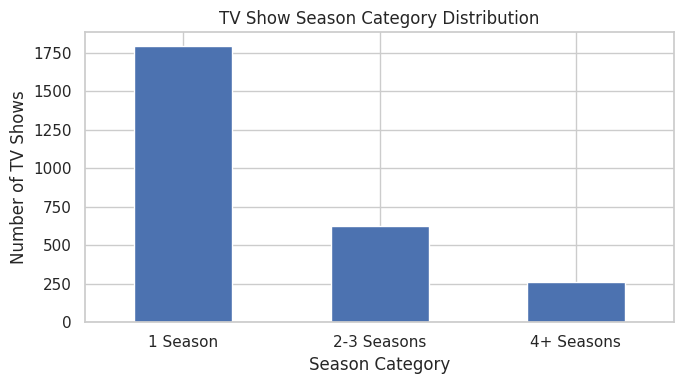

In [ ]:
plt.figure(figsize=(7, 4))
season_counts = df[df["type"] == "TV Show"]["season_category"].value_counts().reindex(["1 Season", "2-3 Seasons", "4+ Seasons"])

season_counts.plot(kind="bar")
plt.title("TV Show Season Category Distribution")
plt.xlabel("Season Category")
plt.ylabel("Number of TV Shows")
plt.xticks(rotation=0)
save_plot("13_season_category_distribution")

In [ ]:
# Save final dataset with engineered features
df.to_csv("Netflix_Final_EDA_With_Features.csv", index=False)
print("Final dataset with new features saved as Netflix_Final_EDA_With_Features.csv")

Final dataset with new features saved as Netflix_Final_EDA_With_Features.csv


## Task 12: Multivariate Analysis

Investigate:
1. Country vs Content Type
2. Year vs Content Type
3. Rating vs Content Type

Use:
- Crosstab
- Heatmaps
- GroupBy

In [ ]:
# Country vs Content Type
country_type_df = df.assign(country_split=df["country"].str.split(",")).explode("country_split")
country_type_df["country_split"] = country_type_df["country_split"].str.strip()

top_country_names = top_10_countries.index.tolist()
country_type_top = country_type_df[country_type_df["country_split"].isin(top_country_names)]

country_type_crosstab = (
    country_type_top
    .groupby(["country_split", "type"])
    .size()
    .unstack(fill_value=0)
)
country_type_crosstab = country_type_crosstab.loc[~country_type_crosstab.index.duplicated(keep="first")]
country_type_crosstab = country_type_crosstab.reindex(pd.Index(top_country_names).unique(), fill_value=0)
if country_type_crosstab.index.duplicated().any():
    country_type_crosstab = country_type_crosstab.groupby(level=0).sum()

country_type_crosstab = country_type_crosstab.loc[~country_type_crosstab.index.duplicated(keep="first")]
country_type_crosstab = country_type_crosstab.reindex(top_country_names, fill_value=0)

if country_type_crosstab.index.duplicated().any():
    country_type_crosstab = country_type_crosstab.groupby(level=0).sum()

country_type_crosstab = country_type_crosstab.reindex(top_country_names, fill_value=0)
country_type_crosstab = country_type_crosstab.reindex(top_country_names)

print("Country vs Content Type Crosstab:")
country_type_crosstab

Country vs Content Type Crosstab:


type,Movie,TV Show
United States,2752,938
India,962,84
United Kingdom,534,272
Canada,319,126
France,303,90
Japan,119,199
Spain,171,61
South Korea,61,170
Germany,182,44
Mexico,111,58


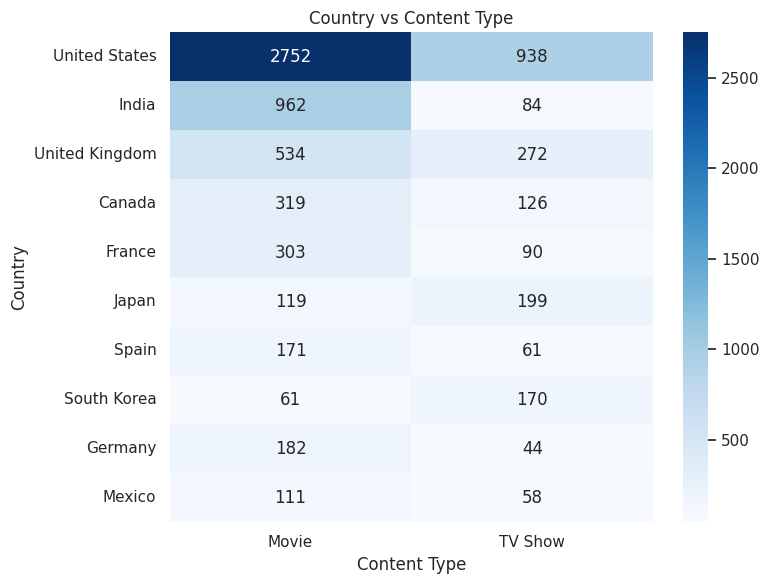

In [ ]:
plt.figure(figsize=(8, 6))
if sns is not None:
    sns.heatmap(country_type_crosstab, annot=True, fmt="d", cmap="Blues")
else:
    plt.imshow(country_type_crosstab, aspect="auto")
    plt.colorbar()
    plt.xticks(range(country_type_crosstab.shape[1]), country_type_crosstab.columns)
    plt.yticks(range(country_type_crosstab.shape[0]), country_type_crosstab.index)

plt.title("Country vs Content Type")
plt.xlabel("Content Type")
plt.ylabel("Country")
save_plot("14_country_vs_content_type_heatmap")

In [ ]:
# Year vs Content Type
year_type_crosstab = pd.crosstab(df["release_year"], df["type"])
year_type_recent = year_type_crosstab[year_type_crosstab.index >= 2000]

print("Year vs Content Type Crosstab:")
year_type_recent.tail()

Year vs Content Type Crosstab:


type,Movie,TV Show
release_year,,
2017,767,265
2018,767,380
2019,633,397
2020,517,436
2021,277,315


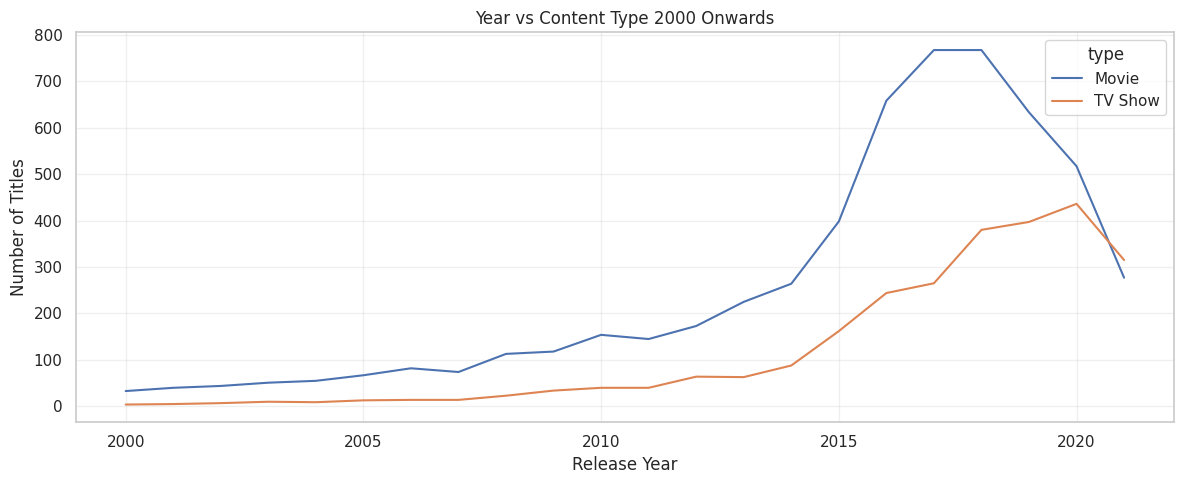

In [ ]:
plt.figure(figsize=(12, 5))
year_type_recent.plot(kind="line", ax=plt.gca())
plt.title("Year vs Content Type 2000 Onwards")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True, alpha=0.3)
save_plot("15_year_vs_content_type_line")

In [ ]:
# Rating vs Content Type
top_ratings = df["rating"].value_counts().head(10).index
rating_type_crosstab = pd.crosstab(df["rating"], df["type"]).loc[top_ratings]

print("Rating vs Content Type Crosstab:")
rating_type_crosstab

Rating vs Content Type Crosstab:


type,Movie,TV Show
rating,,
TV-MA,2062,1145
TV-14,1427,733
TV-PG,540,323
R,797,2
PG-13,490,0
TV-Y7,139,195
TV-Y,131,176
PG,287,0
TV-G,126,94


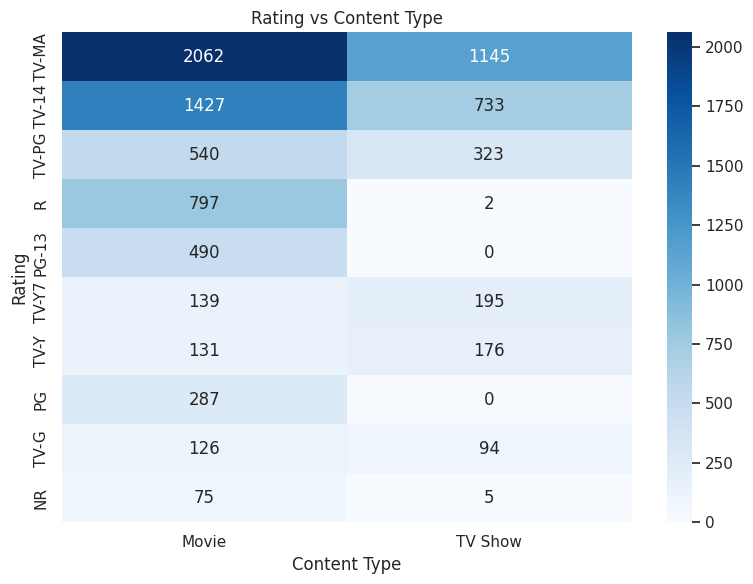

In [ ]:
plt.figure(figsize=(8, 6))
if sns is not None:
    sns.heatmap(rating_type_crosstab, annot=True, fmt="d", cmap="Blues")
else:
    plt.imshow(rating_type_crosstab, aspect="auto")
    plt.colorbar()
    plt.xticks(range(rating_type_crosstab.shape[1]), rating_type_crosstab.columns)
    plt.yticks(range(rating_type_crosstab.shape[0]), rating_type_crosstab.index)

plt.title("Rating vs Content Type")
plt.xlabel("Content Type")
plt.ylabel("Rating")
save_plot("16_rating_vs_content_type_heatmap")

In [ ]:
# GroupBy Analysis
groupby_summary = df.groupby("type").agg(
    total_titles=("title", "count"),
    average_release_year=("release_year", "mean"),
    average_content_age=("content_age", "mean"),
    average_movie_duration=("movie_duration_min", "mean"),
    average_tv_seasons=("tv_seasons", "mean")
).round(2)

groupby_summary

,total_titles,average_release_year,average_content_age,average_movie_duration,average_tv_seasons
type,,,,,
Movie,6131,2013.12,12.88,99.56,NaN
TV Show,2676,2016.61,9.39,NaN,1.76


## Extra Analysis: Top Directors

In [ ]:
director_series = (
    df["director"]
    .replace("Unknown", np.nan)
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

top_10_directors = director_series.value_counts().head(10)

print("Top 10 Directors:")
print(top_10_directors)

Top 10 Directors:
director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Martin Scorsese        12
Youssef Chahine        12
Jay Chapman            12
Name: count, dtype: int64


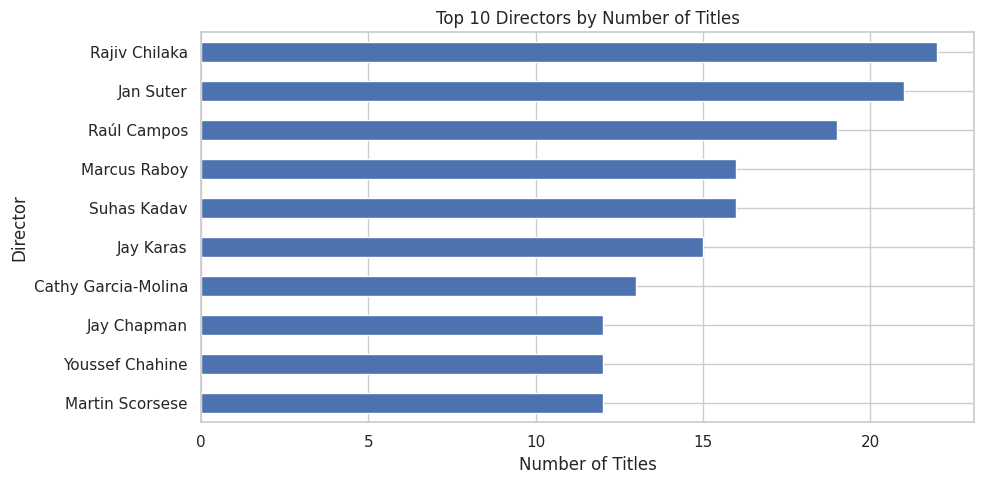

In [ ]:
plt.figure(figsize=(10, 5))
top_10_directors.sort_values().plot(kind="barh")
plt.title("Top 10 Directors by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
save_plot("17_top_10_directors")

## Task 13: Business Insights and Strategic Recommendations

In [ ]:
movies_count = int(type_counts.get("Movie", 0))
tv_count = int(type_counts.get("TV Show", 0))
movie_pct = round(type_percentage.get("Movie", 0), 2)
tv_pct = round(type_percentage.get("TV Show", 0), 2)
top_country = top_10_countries.index[0]
top_country_count = int(top_10_countries.iloc[0])
top_genre = top_10_genres.index[0]
common_rating = rating_counts.idxmax()

print("5 Business Insights")
print("1. Movies dominate the platform with", movies_count, "titles, which is", movie_pct, "% of the dataset.")
print("2. TV Shows account for", tv_count, "titles, which is", tv_pct, "% of the dataset.")
print("3.", top_country, "is the highest content-producing country with", top_country_count, "titles.")
print("4. The most common maturity rating is", common_rating, ", showing Netflix has strong focus on mature/teen audiences.")
print("5. The most popular genre is", top_genre, ", showing strong demand for globally appealing content.")
print("6. Average movie duration is", average_movie_duration, "minutes.")

print("\n3 Strategic Recommendations")
print("1. Netflix should continue investing in movies because they form the largest part of the catalog.")
print("2. Netflix should expand international and country-specific content because global genres and countries strongly dominate the library.")
print("3. Netflix should balance mature-rated content with family and youth-friendly content to attract wider audience segments.")

5 Business Insights
1. Movies dominate the platform with 6131 titles, which is 69.62 % of the dataset.
2. TV Shows account for 2676 titles, which is 30.38 % of the dataset.
3. United States is the highest content-producing country with 3690 titles.
4. The most common maturity rating is TV-MA , showing Netflix has strong focus on mature/teen audiences.
5. The most popular genre is International Movies , showing strong demand for globally appealing content.
6. Average movie duration is 99.56 minutes.

3 Strategic Recommendations
1. Netflix should continue investing in movies because they form the largest part of the catalog.
2. Netflix should expand international and country-specific content because global genres and countries strongly dominate the library.
3. Netflix should balance mature-rated content with family and youth-friendly content to attract wider audience segments.


In [ ]:
import zipfile

with zipfile.ZipFile("netflix_eda_graphs.zip", "r") as zip_ref:
    zip_ref.extractall("netflix_eda_graphs")

In [ ]:
import zipfile

with zipfile.ZipFile("netflix_eda_graphs.zip", "r") as z:
    print(z.namelist())

['15_year_vs_content_type_line.png', '04_yearly_trend_line.png', '06_rating_distribution.png', '08_movie_duration_histogram.png', '11_content_age_distribution.png', '02_content_type_pie.png', '13_season_category_distribution.png', '05_yearly_trend_bar.png', '16_rating_vs_content_type_heatmap.png', '12_duration_category_distribution.png', '01_content_type_count.png', '03_top_10_countries.png', '17_top_10_directors.png', '14_country_vs_content_type_heatmap.png', '07_top_10_genres.png', '10_release_decade_distribution.png', '09_movie_duration_boxplot.png']


In [ ]:
import shutil

# Folder ko dobara zip banao
shutil.make_archive(
    base_name="/content/netflix_eda_graphs_new",
    format="zip",
    root_dir="/content",
    base_dir="netflix_eda_graphs"
)

print("New ZIP created successfully!")

New ZIP created successfully!


In [ ]:
from google.colab import files

files.download("/content/netflix_eda_graphs_new.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>